# Lossless Preparation of Piecewise-constant Signal 

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation

A sinc signal is generated as a representative smooth non-periodic waveform for transform-domain sparsity analysis.

In [3]:
n = 10    # Number of qubit
N = 2**n  # Number of quantum basis

signal = np.zeros(N)
signal[:N//4] =  1.0
signal[N//4:N//2] = -1.0
signal[N//2:] =  0.5

target_f = signal / np.linalg.norm(signal)

### Visualization of the Piecewise Constant Signal

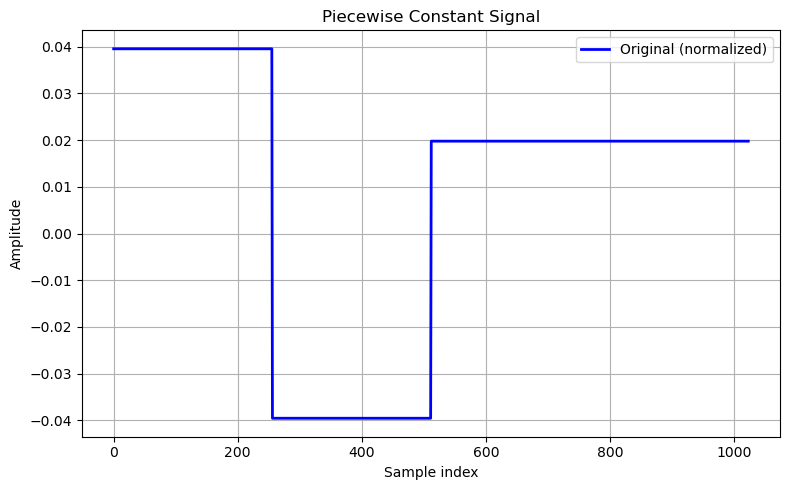

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Piecewise Constant Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Piecewise-Constant Signal
### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [8]:
results = search_sparse_haar_representations(
    signal,
    tolerance=0.04
)

Level=5 | Threshold=5.657e-03 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=1.131e-02 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=2.828e-02 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=5.657e-02 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=1.131e-01 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=2.828e-01 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=5 | Threshold=5.657e-01 | Nonzero=32 | Sparsity=0.031 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=6 | Threshold=8.000e-03 | Nonzero=16 | Sparsity=0.016 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=6 | Threshold=1.600e-02 | Nonzero=16 | Sparsity=0.016 | Trace Distance=0.000000e+00 | Fidelity=1.000000
Level=6 | 

In [7]:
# Apply 7-level discrete packet Haar wavelet transformation on Piecewise Constant Signal
level = 7
X = haar_packet_transform(signal, level)

In [10]:
# The Non-zero coefficients after 7-level DPHWT
np.nonzero(X)

(array([0, 1, 2, 3, 4, 5, 6, 7]),)

### Normalization
The `X_norm` is the output of Phase I.

In [11]:
X_norm = X/np.linalg.norm(X)

### Classical Signal Reconstruction

In [12]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [13]:
TD = trace_distance(x_rec, target_f)

### Visualization

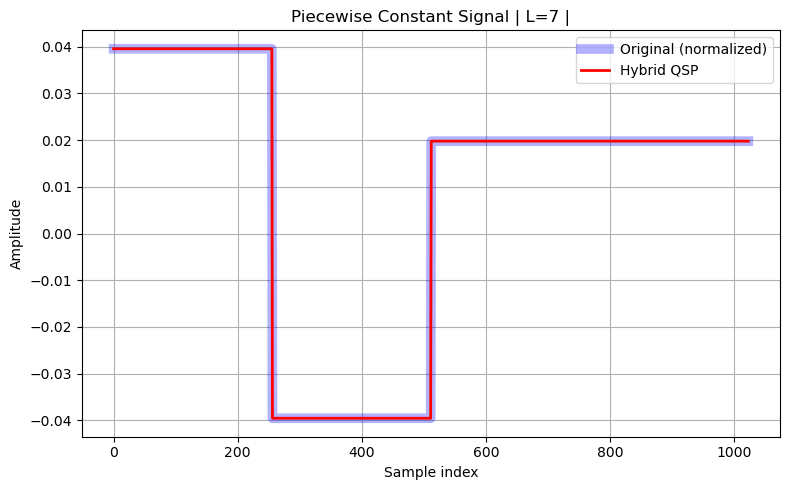

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Piecewise Constant Signal | L={level} |")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/Piecewise_Constant_Signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [19]:
from qibo import Circuit, gates
from qibo.models.encodings import binary_encoder
from qibo.ui import plot_circuit

In [52]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for the reconstructed signal
nqubits = int(np.log2(len(vec)))

# Initialize the full quantum circuit
qc = Circuit(nqubits)

# Prepare a compressed 3-qubit quantum state
# using the first 2^3 sparse coefficients
encoder = binary_encoder(
    nqubits=3,
    data=vec[0:8]
)

# Embed the compressed state preparation
# circuit into the full quantum register
qc.add(
    encoder.on_qubits(7, 8, 9)
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Print decomposed circuit statistics
# for resource analysis
print(
    qc.decompose().decompose().summary()
)

Circuit depth = 55
Total number of gates = 164
Number of qubits = 10
Most common gates:
cx: 136
h: 15
ry: 13
None


### Statevector of the Quantum SQSP and Quantum Decompression

In [46]:
result = qc()

state = result.state()

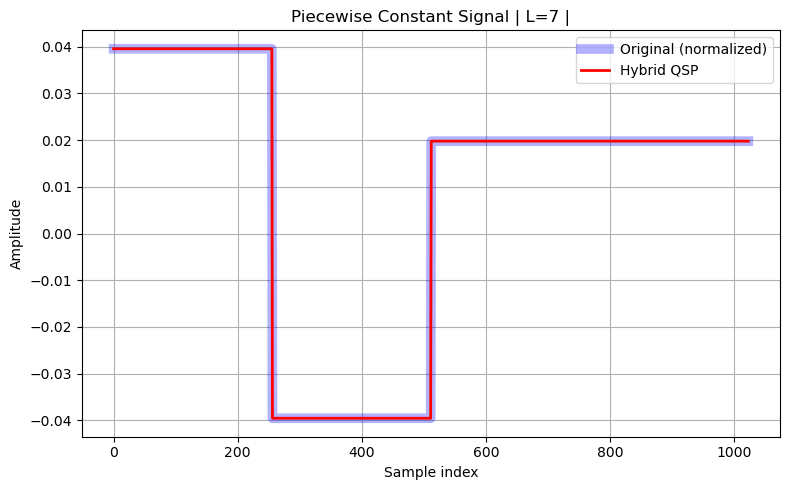

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Piecewise Constant Signal | L={level} |")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()